In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import classification_report, roc_auc_score, roc_curve


df = pd.read_csv('data/bank-additional-full.csv', sep=';')


y = df['y'].map({'yes': 1, 'no': 0})
X = df.drop(['y', 'duration'], axis=1) 
# we drop duration following the papers instuctions for data leakage

# Split Stratify for keeping the 11% "yes" analogy due to the imbalance
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [2]:
# categorical based on the histogram
initial_categorical_cols = ['job','marital','education','default','housing','loan',
                   'contact','month','day_of_week', 'poutcome']

# continuous based on the histogram
initial_numeric_cols = ['age', 'campaign', 'emp.var.rate', 'cons.price.idx', 
               'cons.conf.idx', 'euribor3m', 'nr.employed']

# Here we classify 2 features as different based on their goal
#This means that for the linear models they will be categorical and for tree based ones will be continuous
blurry_features = ['previous', 'pdays']

In [3]:
#preprocessing for LR, KNN, SVM
linear_transformer = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), initial_numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), initial_categorical_cols + blurry_features)
    ])

#preprocessing for RF
tree_transformer = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', initial_numeric_cols + blurry_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), initial_categorical_cols)
    ])

#preprocessing for Catboost none
cat_indices = [X_train.columns.get_loc(col) for col in initial_categorical_cols]

#pilot for catboost pipeline
cst_transformer=None


In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier
from sklearn.neighbors import KNeighborsClassifier

models = {
    'logreg': {
        'model': LogisticRegression(class_weight='balanced', max_iter=1000, solver='liblinear',random_state=42),
        'preprocessor': linear_transformer,
        'params': {
            'classifier__C': [0.1, 1, 10],
            'classifier__penalty': ['l1', 'l2']
        }
    },
        
    'rf': {
        'model': RandomForestClassifier(class_weight='balanced', random_state=42),
        'preprocessor': tree_transformer,
        'params': {
            'classifier__n_estimators': [100, 200],
            'classifier__max_depth': [10, 20]
        }
        
    },
    'knn': {
        'model': KNeighborsClassifier(),
        'preprocessor': linear_transformer,
        'params': {
            'classifier__n_neighbors': [5, 11, 21],
            'classifier__weights': ['uniform', 'distance']
        }
    },
   
    
}

In [ ]:
results = []
best_models = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, config in models.items():
    print(f"Training {name}...")
    pipe = Pipeline([
        ('preprocessor', config['preprocessor']),
        ('classifier', config['model'])
    ])
    
    grid = GridSearchCV(pipe, config['params'], cv=cv, scoring='roc_auc', n_jobs=-1)
    grid.fit(X_train, y_train)
    
    #Test AUC
    best_model = grid.best_estimator_
    y_proba = best_model.predict_proba(X_test)[:, 1]
    test_auc = roc_auc_score(y_test, y_proba)
    
    
    best_models[name] = best_model
    results.append({
        'Model': name,
        'Best AUC (CV)': grid.best_score_,
        'Test AUC': test_auc,  
        'Params': grid.best_params_
    })


results_df = pd.DataFrame(results).sort_values(by='Test AUC', ascending=False)


Training logreg...


/Users/gzempilisgmail.com/Desktop/Projec_ML/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/gzempilisgmail.com/Desktop/Projec_ML/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/gzempilisgmail.com/Desktop/Projec_ML/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: In

Training rf...
Training knn...


/Users/gzempilisgmail.com/Desktop/Projec_ML/.venv/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [11] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/gzempilisgmail.com/Desktop/Projec_ML/.venv/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [11] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/gzempilisgmail.com/Desktop/Projec_ML/.venv/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [11] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/gzempilisgmail.com/Desktop/Projec_ML/.venv/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in col

In [6]:
print(results_df)

    Model  Best AUC (CV)  Test AUC  \
1      rf       0.795806  0.813332   
0  logreg       0.790106  0.801175   
2     knn       0.761980  0.779851   

                                              Params  
1  {'classifier__max_depth': 10, 'classifier__n_e...  
0  {'classifier__C': 0.1, 'classifier__penalty': ...  
2  {'classifier__n_neighbors': 21, 'classifier__w...  


In [7]:
print(best_models)

{'logreg': Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'campaign',
                                                   'emp.var.rate',
                                                   'cons.price.idx',
                                                   'cons.conf.idx', 'euribor3m',
                                                   'nr.employed']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['job', 'marital',
                                                   'education', 'default',
                                                   'housing', 'loan', 'contact',
                                                   'month', 'day_of_week',
 

In [8]:
if 'rf' in best_models:
    y_proba_rf = best_models['rf'].predict_proba(X_test)[:, 1]
    

if 'logreg' in best_models:
    y_proba_logreg = best_models['logreg'].predict_proba(X_test)[:, 1]
   

if 'knn' in best_models:
    y_proba_knn = best_models['knn'].predict_proba(X_test)[:, 1]
 

In [9]:
print("Training CatBoost...")


final_cat = CatBoostClassifier(
    auto_class_weights='Balanced', 
    iterations=650, 
    depth=6, 
    learning_rate=0.05,
    verbose=0, 
    random_state=42,
    l2_leaf_reg=3
)


final_cat.fit(X_train, y_train, cat_features=initial_categorical_cols)

y_proba_cat = final_cat.predict_proba(X_test)[:, 1]
cat_auc = roc_auc_score(y_test, y_proba_cat)

print(f"--- Result ---")
print(f"CatBoost Final Test AUC: {cat_auc:.4f}")

Training CatBoost...
--- Result ---
CatBoost Final Test AUC: 0.8157


In [ ]:
from catboost import cv, Pool

#CV for CatBoost
cv_data = Pool(data=X_train, label=y_train, cat_features=initial_categorical_cols)


params = {
    'iterations': 650,
    'learning_rate': 0.05, 
    'depth': 6,
    'loss_function': 'Logloss',
    'eval_metric': 'AUC',
    'auto_class_weights': 'Balanced',
    'random_seed': 42,
    'verbose': False,
    'l2_leaf_reg':3
}


cv_results = cv(
    params=params,
    pool=cv_data,
    fold_count=5,
    inverted=False,
    shuffle=True,
    partition_random_seed=42,
    stratified=True
)


mean_cv_auc = cv_results['test-AUC-mean'].max()
std_cv_auc = cv_results['test-AUC-std'][cv_results['test-AUC-mean'].idxmax()]

print(f"--- CatBoost CV Results ---")
print(f"Mean CV AUC: {mean_cv_auc:.4f} (+/- {std_cv_auc:.4f})")

Training on fold [0/10]

bestTest = 0.78584306
bestIteration = 309

Training on fold [1/10]

bestTest = 0.8072408727
bestIteration = 250

Training on fold [2/10]

bestTest = 0.8066959561
bestIteration = 520

Training on fold [3/10]

bestTest = 0.7976035302
bestIteration = 467

Training on fold [4/10]

bestTest = 0.8079090785
bestIteration = 379

Training on fold [5/10]

bestTest = 0.814288111
bestIteration = 248

Training on fold [6/10]

bestTest = 0.7956478774
bestIteration = 174

Training on fold [7/10]

bestTest = 0.7990706155
bestIteration = 620

Training on fold [8/10]

bestTest = 0.8032856802
bestIteration = 524

Training on fold [9/10]

bestTest = 0.8115508289
bestIteration = 429

--- CatBoost CV Results ---
Mean CV AUC: 0.8014 (+/- 0.0085)


In [11]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, precision_score, recall_score


y_pred_cat = final_cat.predict(X_test)

print("--- FULL METRICS REPORT (CatBoost) ---")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_cat):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_cat):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_cat):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_cat):.4f}")
print(f"AUC Score: {roc_auc_score(y_test, y_proba_cat):.4f}")

print("\n--- Confusion Matrix ---")
cm = confusion_matrix(y_test, y_pred_cat)
print(cm)

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred_cat))

--- FULL METRICS REPORT (CatBoost) ---
Accuracy:  0.8435
Precision: 0.3870
Recall:    0.6659
F1-Score:  0.4895
AUC Score: 0.8157

--- Confusion Matrix ---
[[6331  979]
 [ 310  618]]

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.95      0.87      0.91      7310
           1       0.39      0.67      0.49       928

    accuracy                           0.84      8238
   macro avg       0.67      0.77      0.70      8238
weighted avg       0.89      0.84      0.86      8238



In [12]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import roc_auc_score, classification_report

##here the svm training is autonomous again because we use a smaller version of the original dataset since it was provided by the authors
df_small = pd.read_csv('bank-additional.csv', sep=';')

y_small = df_small['y'].map({'yes': 1, 'no': 0})
X_small = df_small.drop(['y', 'duration'], axis=1)


X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_small, y_small, test_size=0.2, random_state=42, stratify=y_small
)


svm_pipe = Pipeline([
    ('preprocessor', linear_transformer), 
    ('classifier', SVC(probability=True, class_weight='balanced', random_state=42))
])

#in the paper only the rbf was used but we will try linear and poly d=2 as well 
svm_param_grid = [
    {
        'classifier__kernel': ['linear', 'rbf'],
        'classifier__C': [0.1, 1, 10]
    },
    {
        'classifier__kernel': ['poly'],
        'classifier__degree': [2],
        'classifier__C': [0.1, 1, 10],
        'classifier__gamma': ['scale']
    }
]

print("Training SVM (Linear vs RBF vs Poly) small dataset...")
svm_grid = GridSearchCV(svm_pipe, svm_param_grid, cv=5, scoring='roc_auc', n_jobs=-1, verbose=1)
svm_grid.fit(X_train_s, y_train_s)


y_proba_svm = svm_grid.predict_proba(X_test_s)[:, 1]
y_pred_svm = svm_grid.predict(X_test_s)

print("\n" + "="*30)
print(f"BEST SVM PARAMS: {svm_grid.best_params_}")
print(f"SVM TEST AUC: {roc_auc_score(y_test_s, y_proba_svm):.4f}")
print("="*30)
print("\nClassification Report (SVM):")
print(classification_report(y_test_s, y_pred_svm))

Training SVM (Linear vs RBF vs Poly) small dataset...
Fitting 5 folds for each of 9 candidates, totalling 45 fits


/Users/gzempilisgmail.com/Desktop/Projec_ML/.venv/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [2, 3, 11] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/gzempilisgmail.com/Desktop/Projec_ML/.venv/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [10, 11] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/gzempilisgmail.com/Desktop/Projec_ML/.venv/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [10] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/gzempilisgmail.com/Desktop/Projec_ML/.venv/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categor


BEST SVM PARAMS: {'classifier__C': 0.1, 'classifier__degree': 2, 'classifier__gamma': 'scale', 'classifier__kernel': 'poly'}
SVM TEST AUC: 0.7603

Classification Report (SVM):
              precision    recall  f1-score   support

           0       0.94      0.88      0.91       734
           1       0.37      0.58      0.45        90

    accuracy                           0.84       824
   macro avg       0.66      0.73      0.68       824
weighted avg       0.88      0.84      0.86       824



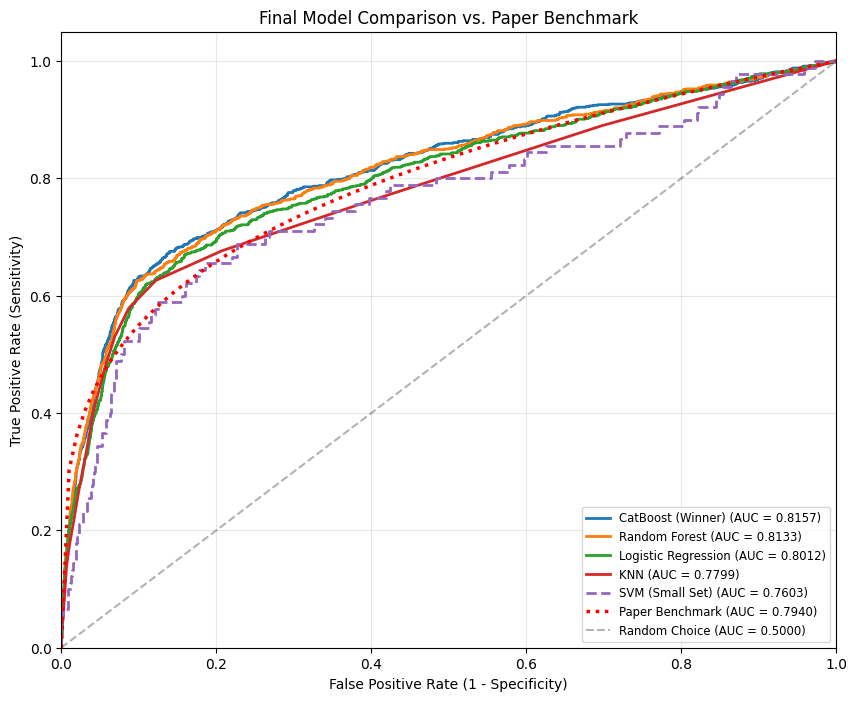

In [13]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
import numpy as np


plt.figure(figsize=(10, 8))


large_models = {
    'CatBoost (Winner)': y_proba_cat,
    'Random Forest': y_proba_rf,
    'Logistic Regression': y_proba_logreg,
    'KNN': y_proba_knn
}

for name, y_proba in large_models.items():
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.4f})', lw=2)

# SVM (Small Set)
fpr_svm, tpr_svm, _ = roc_curve(y_test_s, y_proba_svm)
roc_auc_svm = auc(fpr_svm, tpr_svm)
plt.plot(fpr_svm, tpr_svm, label=f'SVM (Small Set) (AUC = {roc_auc_svm:.4f})', linestyle='--', lw=2)


x_bench = np.linspace(0, 1, 100)
y_bench = x_bench**(1/3.85) 
plt.plot(x_bench, y_bench, 'r:', label='Paper Benchmark (AUC = 0.7940)', lw=2.5)


plt.plot([0, 1], [0, 1], color='black', linestyle='--', alpha=0.3, label='Random Choice (AUC = 0.5000)')


plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('Final Model Comparison vs. Paper Benchmark')
plt.legend(loc="lower right", fontsize='small', frameon=True)
plt.grid(alpha=0.3)

plt.show()

In [14]:



y_true = np.array(y_test)
y_probs = np.array(y_proba_cat) 


data = pd.DataFrame({'true': y_true, 'prob': y_probs})
data = data.sort_values(by='prob', ascending=False).reset_index(drop=True)


total_positives = data['true'].sum()
percentages = [0.1, 0.2, 0.5] 

print(f"{'Clients percentage':<20} | {'Succes percentage (Recall)':<25} | {'Lift Score':<10}")
print("-" * 65)

for p in percentages:
    num_customers = int(len(data) * p)
    positives_reached = data.loc[:num_customers, 'true'].sum()
    
    recall_at_p = (positives_reached / total_positives) * 100
    lift_score = (positives_reached / total_positives) / p
    
    print(f"{int(p*100):>13}% {'':<5} | {recall_at_p:>20.2f}% {'':<3} | {lift_score:>8.2f}")

Clients percentage   | Succes percentage (Recall) | Lift Score
-----------------------------------------------------------------
           10%       |                48.28%     |     4.83
           20%       |                67.46%     |     3.37
           50%       |                84.27%     |     1.69


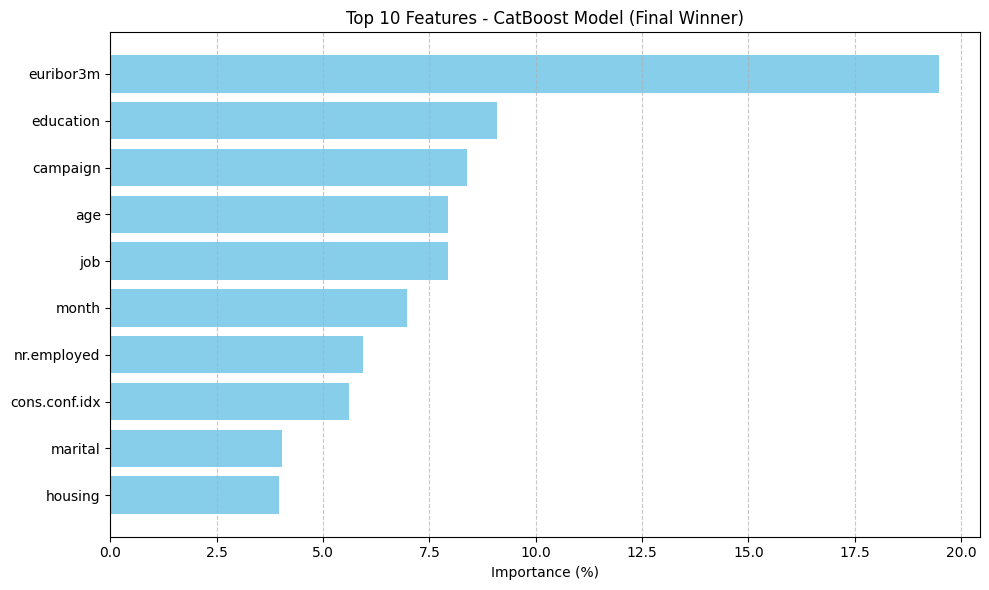

--- Feature impoertance ---
          Feature  Importance
17      euribor3m   19.469946
3       education    9.089120
10       campaign    8.378983
0             age    7.938327
1             job    7.928744
8           month    6.977064
18    nr.employed    5.942937
16  cons.conf.idx    5.605014
2         marital    4.029509
5         housing    3.960826


In [15]:
#feature importance
feature_importance = final_cat.get_feature_importance()
feature_names = X_train.columns


fi_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
})


fi_df = fi_df.sort_values(by='Importance', ascending=False).head(10)

plt.figure(figsize=(10, 6))
plt.barh(fi_df['Feature'], fi_df['Importance'], color='skyblue')
plt.xlabel('Importance (%)')
plt.title('Top 10 Features - CatBoost Model (Final Winner)')
plt.gca().invert_yaxis()  
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("--- Feature impoertance ---")
print(fi_df)